In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime, timedelta
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import scipy.optimize as sco
import cvxpy as cp

In [14]:
tickers = yf.Tickers('CBA.AX BHP.AX CSL.AX WES.AX MQG.AX')
dt_tickers = ['CBA.AX', 'BHP.AX', 'CSL.AX', 'WES.AX', 'MQG.AX']
data = yf.download(dt_tickers, start="2021-01-01", end="2025-12-31")

[*********************100%***********************]  5 of 5 completed


In [15]:
info = tickers.tickers['CBA.AX'].info
print(info.keys())

for ticker, obj in tickers.tickers.items():
    info = obj.info
    print(f"{ticker}: {info['longName']} | Sector: {info['sector']} | Market Cap: {info['marketCap']}")


dict_keys(['address1', 'address2', 'city', 'state', 'zip', 'country', 'phone', 'website', 'industry', 'industryKey', 'industryDisp', 'sector', 'sectorKey', 'sectorDisp', 'longBusinessSummary', 'fullTimeEmployees', 'companyOfficers', 'auditRisk', 'boardRisk', 'compensationRisk', 'shareHolderRightsRisk', 'overallRisk', 'governanceEpochDate', 'compensationAsOfEpochDate', 'executiveTeam', 'maxAge', 'priceHint', 'previousClose', 'open', 'dayLow', 'dayHigh', 'regularMarketPreviousClose', 'regularMarketOpen', 'regularMarketDayLow', 'regularMarketDayHigh', 'dividendRate', 'dividendYield', 'exDividendDate', 'payoutRatio', 'fiveYearAvgDividendYield', 'beta', 'trailingPE', 'forwardPE', 'volume', 'regularMarketVolume', 'averageVolume', 'averageVolume10days', 'averageDailyVolume10Day', 'bid', 'ask', 'bidSize', 'askSize', 'marketCap', 'nonDilutedMarketCap', 'fiftyTwoWeekLow', 'fiftyTwoWeekHigh', 'allTimeHigh', 'allTimeLow', 'priceToSalesTrailing12Months', 'fiftyDayAverage', 'twoHundredDayAverage', '

In [16]:
close_prices = data['Close']
close_prices.head()

Ticker,BHP.AX,CBA.AX,CSL.AX,MQG.AX,WES.AX
Date,,,,,
2021-01-04,26.078039,68.612602,262.952362,115.206894,41.920712
2021-01-05,26.829010,68.186592,263.524414,114.474518,41.709114
2021-01-06,26.774500,67.916237,256.844452,111.767159,41.090595
2021-01-07,28.403624,69.292595,253.725967,113.931412,41.464962
2021-01-08,28.264330,70.152809,258.569855,115.988663,42.197411


In [17]:
returns = close_prices.pct_change().dropna()
returns.head()

Ticker,BHP.AX,CBA.AX,CSL.AX,MQG.AX,WES.AX
Date,,,,,
2021-01-05,0.028797,-0.006209,0.002175,-0.006357,-0.005048
2021-01-06,-0.002032,-0.003965,-0.025349,-0.023650,-0.014829
2021-01-07,0.060846,0.020266,-0.012142,0.019364,0.009111
2021-01-08,-0.004904,0.012414,0.019091,0.018057,0.017664
2021-01-11,-0.003643,-0.005489,-0.015344,-0.006669,-0.008872


In [18]:
mean_returns = returns.mean()
cov_matrix = returns.cov()

print("Mean Daily Returns:")
print(mean_returns)
print("\nCovariance Matrix:")
print(cov_matrix)


Mean Daily Returns:
Ticker
BHP.AX    0.000549
CBA.AX    0.000744
CSL.AX   -0.000237
MQG.AX    0.000545
WES.AX    0.000595
dtype: float64

Covariance Matrix:
Ticker    BHP.AX    CBA.AX    CSL.AX    MQG.AX    WES.AX
Ticker                                                  
BHP.AX  0.000259  0.000036  0.000011  0.000073  0.000030
CBA.AX  0.000036  0.000154  0.000045  0.000084  0.000072
CSL.AX  0.000011  0.000045  0.000209  0.000061  0.000048
MQG.AX  0.000073  0.000084  0.000061  0.000212  0.000086
WES.AX  0.000030  0.000072  0.000048  0.000086  0.000152


In [19]:
# Monte Carlo simulation parameters
num_portfolios = 10000
num_stocks = len(mean_returns)
trading_days = 252

results = np.zeros((3, num_portfolios))
weights_record = []

for i in range(num_portfolios):
    # Randomly generate portfolio weights
    weights = np.random.random(num_stocks) 
    # Normalise weights to sum to 1
    weights /= np.sum(weights)
    # Save the combination of weights for later analysis
    weights_record.append(weights)

    # Calculate portfolio return in annualised termss
    portfolio_return = np.sum(mean_returns * weights) * trading_days

    # Calculate portfolio volatility
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix * trading_days, weights)))

    # Sharpe ratio (assuming risk-free rate of 4% for Australia)
    sharpe_ratio = (portfolio_return - 0.04) / port_volatility

    # Results
    results[0, i] = portfolio_return
    results[1, i] = port_volatility
    results[2, i] = sharpe_ratio

    print(results.shape)
    print(results[:, :5])  # show first 5 portfolios

(3, 10000)
[[0.06129689 0.         0.         0.         0.        ]
 [0.15144366 0.         0.         0.         0.        ]
 [0.14062581 0.         0.         0.         0.        ]]
(3, 10000)
[[0.06129689 0.09400872 0.         0.         0.        ]
 [0.15144366 0.14240284 0.         0.         0.        ]
 [0.14062581 0.37926715 0.         0.         0.        ]]
(3, 10000)
[[0.06129689 0.09400872 0.17500508 0.         0.        ]
 [0.15144366 0.14240284 0.17279685 0.         0.        ]
 [0.14062581 0.37926715 0.78129362 0.         0.        ]]
(3, 10000)
[[0.06129689 0.09400872 0.17500508 0.07480428 0.        ]
 [0.15144366 0.14240284 0.17279685 0.1445377  0.        ]
 [0.14062581 0.37926715 0.78129362 0.24079727 0.        ]]
(3, 10000)
[[0.06129689 0.09400872 0.17500508 0.07480428 0.11654148]
 [0.15144366 0.14240284 0.17279685 0.1445377  0.16115861]
 [0.14062581 0.37926715 0.78129362 0.24079727 0.47494501]]
(3, 10000)
[[0.06129689 0.09400872 0.17500508 0.07480428 0.11654148]
 

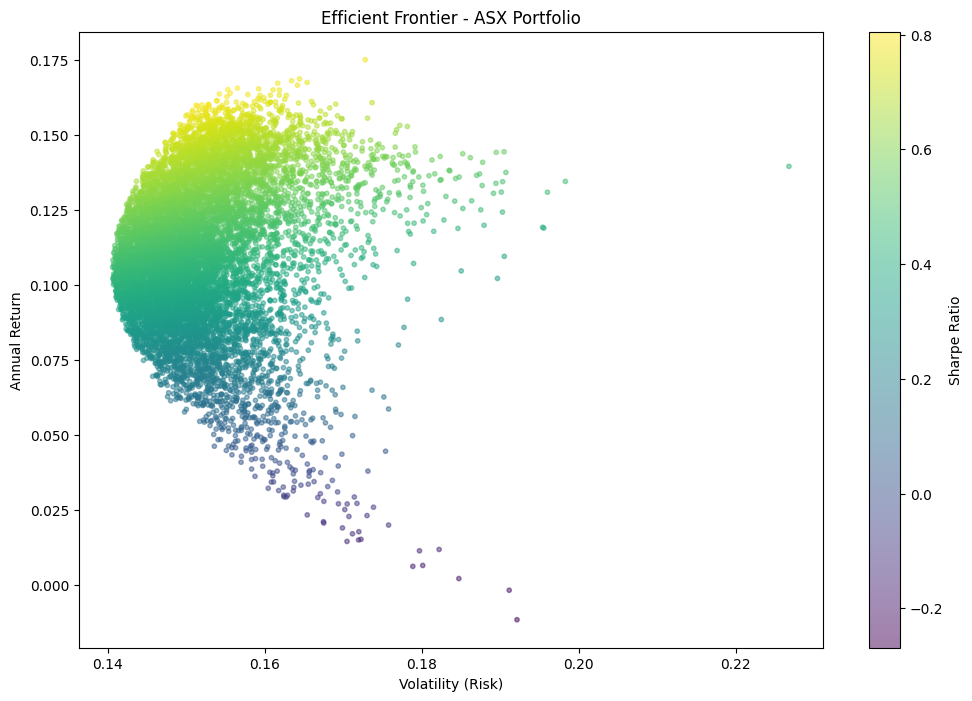

In [20]:
# Plotting the result.
plt.figure(figsize=(12, 8))
plt.scatter(results[1], results[0], c=results[2], cmap='viridis', alpha=0.5, s=10)
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Volatility (Risk)')
plt.ylabel('Annual Return')
plt.title('Efficient Frontier - ASX Portfolio')
plt.show()

In [21]:
# Maximum Sharpe Ratio Portfolio
max_sharpe_idx = np.argmax(results[2])
max_sharpe_return = results[0, max_sharpe_idx]
max_sharpe_volatility = results[1, max_sharpe_idx]
max_sharpe_ratio = results[2, max_sharpe_idx]
max_sharpe_weights = weights_record[max_sharpe_idx]

print("Max Sharpe Ratio Portfolio:")
print(f"Return:{max_sharpe_return:.4f}")
print(f"Volatility:{max_sharpe_volatility: .4f}")
print(f"Sharpe Ratio:{max_sharpe_ratio: .4f}")
print(f"Weights: {max_sharpe_weights}")

Max Sharpe Ratio Portfolio:
Return:0.1650
Volatility: 0.1553
Sharpe Ratio: 0.8050
Weights: [0.17556732 0.53917974 0.01385139 0.01932459 0.25207696]


In [23]:
# Minimum Covariance Ratio Portfolio
min_var_idx = np.argmin(results[1])
min_var_return = results[0, min_var_idx]
min_var_volatility = results[1, min_var_idx]
min_var_sharpe = results[2, min_var_idx]
min_var_weights = weights_record[min_var_idx]

print("Minimum Variance Portfolio:")
print(f"Return: {min_var_return: .4f}")
print(f"Volatility: {min_var_volatility: .4f}")
print(f"Sharpe Ratio: {min_var_sharpe: .4f}")
print(f"Weights: {min_var_weights}")

Minimum Variance Portfolio:
Return:  0.1058
Volatility:  0.1406
Sharpe Ratio:  0.4683
Weights: [0.21672715 0.24473188 0.2415152  0.00984389 0.28718189]


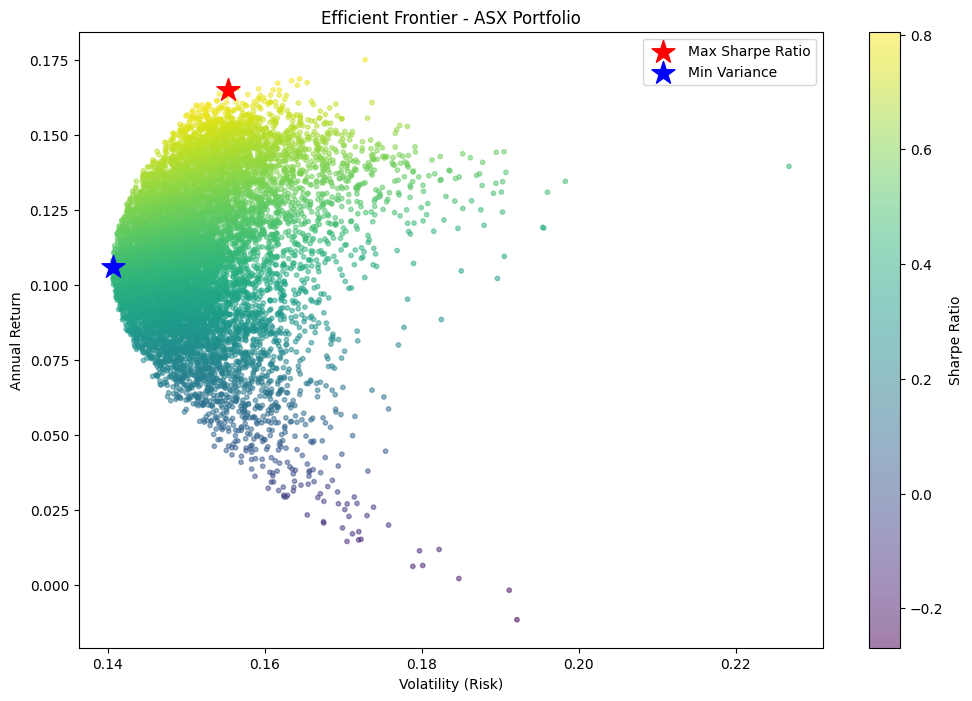

In [24]:
plt.figure(figsize=(12, 8))

# plot all portfolios
plt.scatter(results[1], results[0], c=results[2], cmap='viridis', alpha=0.5, s=10)
plt.colorbar(label='Sharpe Ratio')

# mark max sharpe portfolio
plt.scatter(max_sharpe_volatility, max_sharpe_return, marker='*', color='red', s=300, label='Max Sharpe Ratio')

# mark minimum variance portfolio
plt.scatter(min_var_volatility, min_var_return, marker='*', color='blue', s=300, label='Min Variance')

plt.xlabel('Volatility (Risk)')
plt.ylabel('Annual Return')
plt.title('Efficient Frontier - ASX Portfolio')
plt.legend()
plt.show()